# 👩‍💻 Optimize Your Training Pipeline with Efficiency Tricks

## 📋 Overview
In this activity, you'll enhance the training efficiency and stability of a Convolutional Neural Network on the CIFAR-10 dataset by integrating advanced techniques such as gradient clipping, learning rate scheduling, and mixed precision training. These optimizations are crucial in real-world machine learning scenarios where computational resources and time are often limited, but model performance cannot be sacrificed.

This activity ties into practical scenarios where you might need to improve model training efficiency and reliability, essential skills for machine learning engineers and data scientists.

## Task 1: Baseline Model Training
**Context:** Start by setting up a baseline training for your CNN model on CIFAR-10.

Epoch [1/5] Train Loss: 1.5230, Train Acc: 0.4480 | Val Loss: 1.1831, Val Acc: 0.5653
Epoch [2/5] Train Loss: 1.0548, Train Acc: 0.6234 | Val Loss: 0.9833, Val Acc: 0.6520
Epoch [3/5] Train Loss: 0.8474, Train Acc: 0.7018 | Val Loss: 0.8770, Val Acc: 0.6949
Epoch [4/5] Train Loss: 0.6842, Train Acc: 0.7619 | Val Loss: 0.8067, Val Acc: 0.7211
Epoch [5/5] Train Loss: 0.5382, Train Acc: 0.8113 | Val Loss: 0.8217, Val Acc: 0.7340


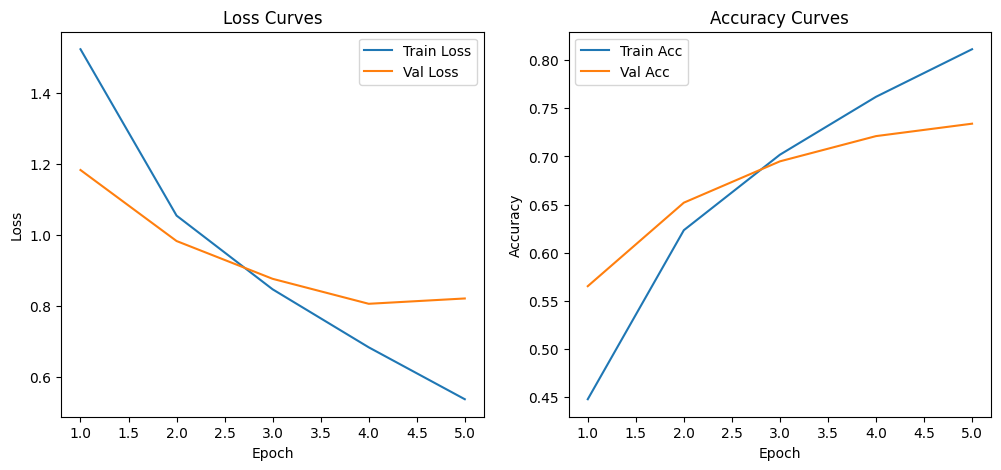

In [1]:
import torch
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
import time
import matplotlib.pyplot as plt
import numpy as np

# Set random seed for reproducibility
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Data preparation
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load CIFAR-10 training and validation datasets
train_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)
val_dataset = datasets.CIFAR10(root='./data', train=False, transform=transform, download=True)

# Create data loaders
train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

# Simple CNN architecture
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        self.fc2 = nn.Linear(512, 10)
    
    def forward(self, x):
        x = self.relu(self.conv1(x))     # 32×32×32
        x = self.pool(x)                 # 32×16×16
        x = self.relu(self.conv2(x))     # 64×16×16
        x = self.pool(x)                 # 64×8×8
        x = x.view(x.size(0), -1)        # flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

        pass

# Training function
def train_baseline(model, train_loader, criterion, optimizer, num_epochs=5):
    start_time = time.time()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        val_loss, val_acc = validate(model, val_loader, criterion)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        train_accuracies.append(epoch_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time

    return train_losses, val_losses, train_accuracies, val_accuracies, total_time
    pass

# Validation function
def validate(model, val_loader, criterion):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_loss = val_loss / len(val_loader)
    accuracy = correct / total
    return avg_loss, accuracy

# Initialize model, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Train the baseline model
num_epochs = 5 # or more when trying out iterations
train_losses, val_losses, train_accuracies, val_accuracies, training_time = train_baseline(
    model, train_loader, criterion, optimizer, num_epochs)

# Plot results
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Train Acc")
plt.plot(epochs, val_accuracies, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curves")
plt.legend()

plt.show()

## Task 2: Applying Gradient Clipping
**Context:** Enhance training stability by incorporating gradient clipping into your model training.

In [8]:
model_gc = SimpleCNN().to(device)
optimizer_gc = optim.SGD(model_gc.parameters(), lr=0.01, momentum=0.9)

In [9]:
def train_with_gradient_clipping(model, train_loader, criterion, optimizer, 
                                 num_epochs=5, max_norm=1.0):

    start_time = time.time()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()

            # 🔥 Gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(), max_norm)

            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        val_loss, val_acc = validate(model, val_loader, criterion)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        train_accuracies.append(epoch_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time

    return train_losses, val_losses, train_accuracies, val_accuracies, total_time

In [11]:
max_norm = 1.0

In [12]:
train_losses_gc, val_losses_gc, train_accuracies_gc, val_accuracies_gc, training_time_gc = train_with_gradient_clipping(
    model_gc, train_loader, criterion, optimizer_gc, num_epochs, max_norm)

Epoch [1/5] Train Loss: 1.6283, Train Acc: 0.4128 | Val Loss: 1.3671, Val Acc: 0.5104
Epoch [2/5] Train Loss: 1.2663, Train Acc: 0.5442 | Val Loss: 1.1814, Val Acc: 0.5794
Epoch [3/5] Train Loss: 1.1030, Train Acc: 0.6078 | Val Loss: 1.0683, Val Acc: 0.6211
Epoch [4/5] Train Loss: 0.9782, Train Acc: 0.6554 | Val Loss: 1.0041, Val Acc: 0.6460
Epoch [5/5] Train Loss: 0.8806, Train Acc: 0.6915 | Val Loss: 0.9301, Val Acc: 0.6726


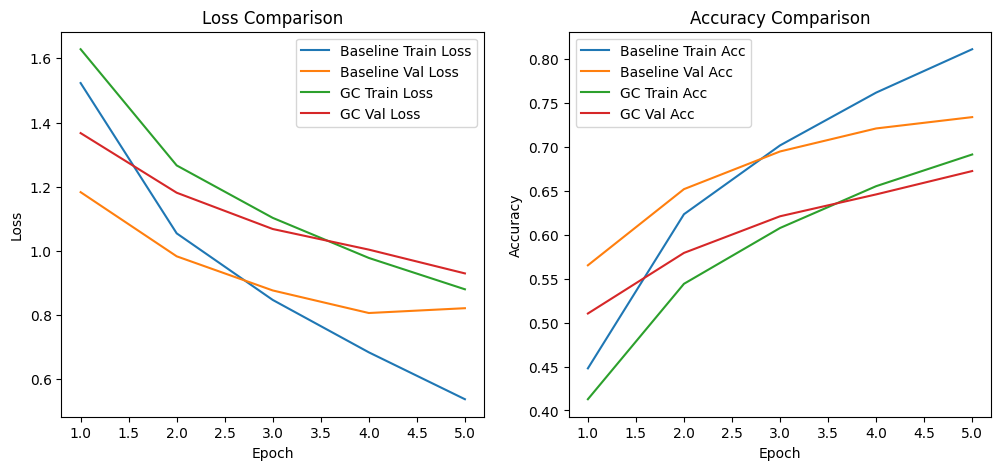

In [13]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12,5))

# Loss comparison
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Baseline Train Loss")
plt.plot(epochs, val_losses, label="Baseline Val Loss")
plt.plot(epochs, train_losses_gc, label="GC Train Loss")
plt.plot(epochs, val_losses_gc, label="GC Val Loss")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy comparison
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Baseline Train Acc")
plt.plot(epochs, val_accuracies, label="Baseline Val Acc")
plt.plot(epochs, train_accuracies_gc, label="GC Train Acc")
plt.plot(epochs, val_accuracies_gc, label="GC Val Acc")
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

## Task 3: Implementing Learning Rate Scheduling
**Context:** Use dynamic learning rates to potentially enhance convergence.

Epoch [1/5] LR: 0.01000 | Train Loss: 1.5303, Train Acc: 0.4473 | Val Loss: 1.2051, Val Acc: 0.5817
Epoch [2/5] LR: 0.00500 | Train Loss: 1.0683, Train Acc: 0.6211 | Val Loss: 1.0076, Val Acc: 0.6480
Epoch [3/5] LR: 0.00500 | Train Loss: 0.8115, Train Acc: 0.7166 | Val Loss: 0.8699, Val Acc: 0.6974
Epoch [4/5] LR: 0.00250 | Train Loss: 0.7027, Train Acc: 0.7536 | Val Loss: 0.8390, Val Acc: 0.7099
Epoch [5/5] LR: 0.00250 | Train Loss: 0.5479, Train Acc: 0.8121 | Val Loss: 0.8148, Val Acc: 0.7242


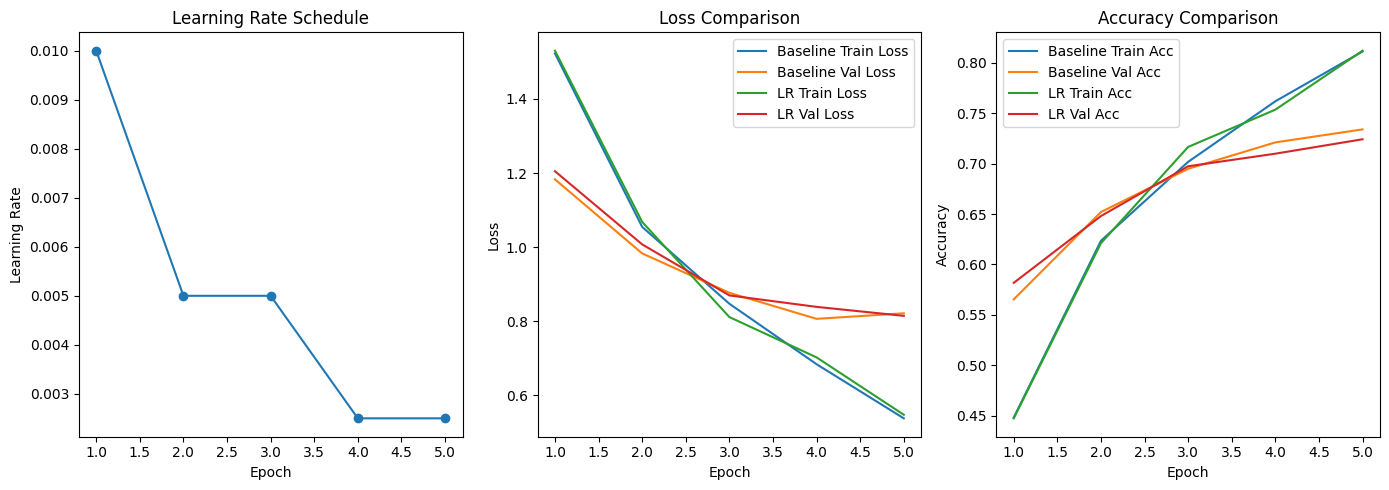

In [14]:
def train_with_lr_scheduler(model, train_loader, criterion, optimizer, scheduler, num_epochs=5):

    start_time = time.time()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []
    lr_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Epoch metrics
        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        # Validation
        val_loss, val_acc = validate(model, val_loader, criterion)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        train_accuracies.append(epoch_acc)
        val_accuracies.append(val_acc)

        # 🔥 Step the scheduler
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(val_loss)
        else:
            scheduler.step()

        # Track LR
        current_lr = optimizer.param_groups[0]['lr']
        lr_history.append(current_lr)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"LR: {current_lr:.5f} | "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time

    return train_losses, val_losses, train_accuracies, val_accuracies, total_time, lr_history

# Initialize model and optimizer for learning rate scheduling
model_lr = SimpleCNN().to(device)
optimizer_lr = optim.SGD(model_lr.parameters(), lr=0.01, momentum=0.9)

scheduler = optim.lr_scheduler.StepLR(optimizer_lr, step_size=2, gamma=0.5)

# Train with learning rate scheduling
train_losses_lr, val_losses_lr, train_accuracies_lr, val_accuracies_lr, training_time_lr, lr_history = train_with_lr_scheduler(
    model_lr, train_loader, criterion, optimizer_lr, scheduler, num_epochs)

# Plot and compare results
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14,5))

# LR schedule
plt.subplot(1,3,1)
plt.plot(epochs, lr_history, marker='o')
plt.title("Learning Rate Schedule")
plt.xlabel("Epoch")
plt.ylabel("Learning Rate")

# Loss comparison
plt.subplot(1,3,2)
plt.plot(epochs, train_losses, label="Baseline Train Loss")
plt.plot(epochs, val_losses, label="Baseline Val Loss")
plt.plot(epochs, train_losses_lr, label="LR Train Loss")
plt.plot(epochs, val_losses_lr, label="LR Val Loss")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy comparison
plt.subplot(1,3,3)
plt.plot(epochs, train_accuracies, label="Baseline Train Acc")
plt.plot(epochs, val_accuracies, label="Baseline Val Acc")
plt.plot(epochs, train_accuracies_lr, label="LR Train Acc")
plt.plot(epochs, val_accuracies_lr, label="LR Val Acc")
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

## Task 4: Experimenting with Mixed Precision 
**Context:** Speed up your training using mixed precision with PyTorch's `torch.cuda.amp`.

In [15]:
from torch.cuda.amp import autocast, GradScaler

def train_with_mixed_precision(model, train_loader, criterion, optimizer, num_epochs=5):

    scaler = GradScaler()  # 1. Create GradScaler
    start_time = time.time()

    train_losses = []
    val_losses = []
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            # 6. Forward pass with autocast
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            # 8. Scale loss and backpropagate
            scaler.scale(loss).backward()

            # 9. (Optional) unscale before clipping
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            # 10–11. Step optimizer through scaler
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc = correct / total

        # Validation
        val_loss, val_acc = validate(model, val_loader, criterion)

        train_losses.append(epoch_loss)
        val_losses.append(val_loss)
        train_accuracies.append(epoch_acc)
        val_accuracies.append(val_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f} "
              f"| Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    total_time = time.time() - start_time

    return train_losses, val_losses, train_accuracies, val_accuracies, total_time

# Check if GPU supports mixed precision
if not torch.cuda.is_available():
    print("CUDA not available. Mixed precision requires CUDA.")
else:
    # Initialize model and optimizer for mixed precision
    model_mp = SimpleCNN().to(device)
    optimizer_mp = optim.SGD(model_mp.parameters(), lr=0.01, momentum=0.9)
    
    # Train with mixed precision
    train_losses_mp, val_losses_mp, train_accuracies_mp, val_accuracies_mp, training_time_mp = train_with_mixed_precision(
        model_mp, train_loader, criterion, optimizer_mp, num_epochs)

Epoch [1/5] Train Loss: 1.6365, Train Acc: 0.4104 | Val Loss: 1.3603, Val Acc: 0.5185
Epoch [2/5] Train Loss: 1.2712, Train Acc: 0.5477 | Val Loss: 1.1759, Val Acc: 0.5836
Epoch [3/5] Train Loss: 1.1075, Train Acc: 0.6107 | Val Loss: 1.0877, Val Acc: 0.6166
Epoch [4/5] Train Loss: 0.9845, Train Acc: 0.6561 | Val Loss: 1.0296, Val Acc: 0.6333
Epoch [5/5] Train Loss: 0.8860, Train Acc: 0.6888 | Val Loss: 0.9509, Val Acc: 0.6716


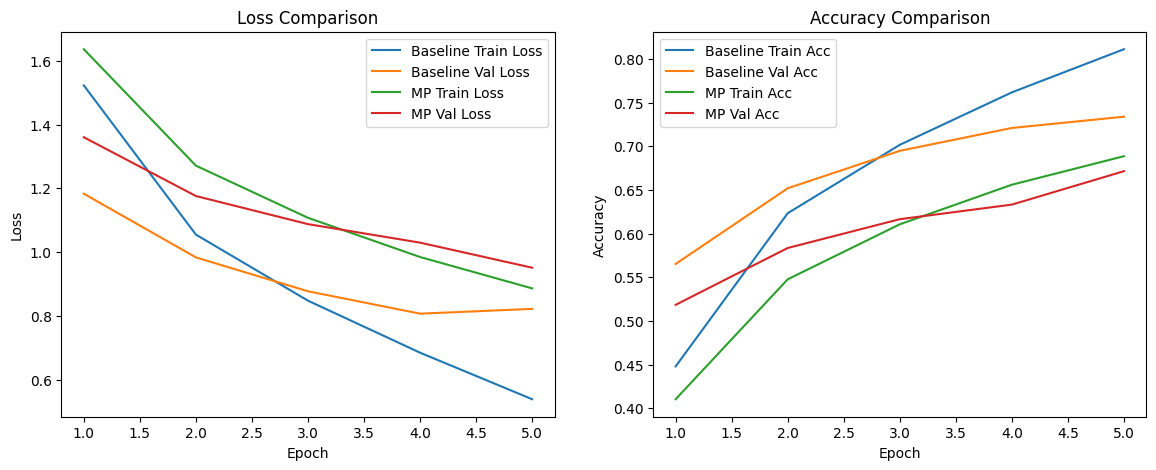

Baseline Training Time: 49.14s
Mixed Precision Training Time: 53.75s


In [16]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(14,5))

# Loss comparison
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, label="Baseline Train Loss")
plt.plot(epochs, val_losses, label="Baseline Val Loss")
plt.plot(epochs, train_losses_mp, label="MP Train Loss")
plt.plot(epochs, val_losses_mp, label="MP Val Loss")
plt.title("Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Accuracy comparison
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, label="Baseline Train Acc")
plt.plot(epochs, val_accuracies, label="Baseline Val Acc")
plt.plot(epochs, train_accuracies_mp, label="MP Train Acc")
plt.plot(epochs, val_accuracies_mp, label="MP Val Acc")
plt.title("Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

print(f"Baseline Training Time: {training_time:.2f}s")
print(f"Mixed Precision Training Time: {training_time_mp:.2f}s")

## Task 5: Analysis and Visualization
**Context:** Visualize and compare outcomes of all optimizations for comprehensive analysis.

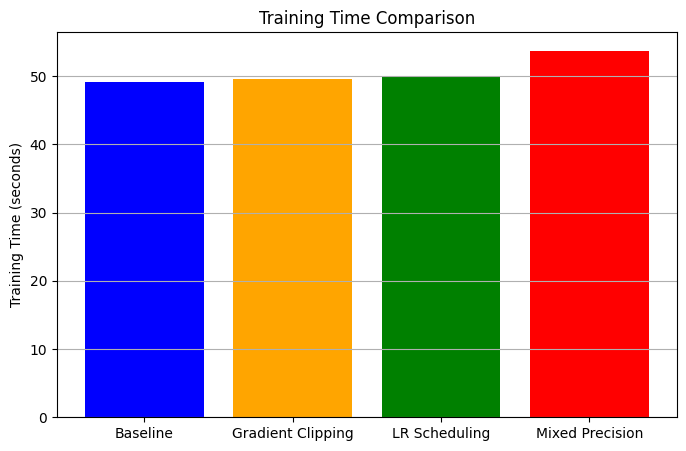

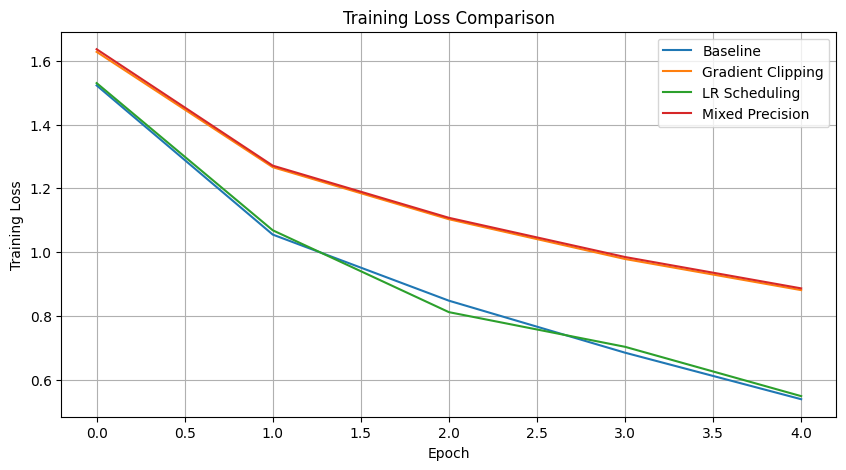

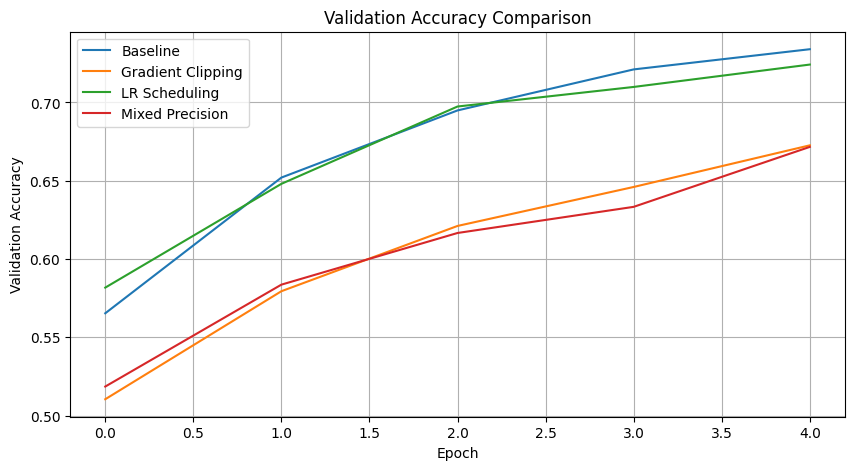

In [17]:
def plot_comparison(metrics_dict, metric_name, title):
    """
    Plot comparison of different training configurations.
    
    Args:
        metrics_dict: Dictionary with configuration names as keys and metric lists as values
        metric_name: Name of the metric being plotted (for axis label)
        title: Plot title
    """
    plt.figure(figsize=(10,5))

    for label, values in metrics_dict.items():
        plt.plot(values, label=label)

    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Prepare data for comparisons
training_times = {
    'Baseline': training_time,
    'Gradient Clipping': training_time_gc,
    'LR Scheduling': training_time_lr,
    'Mixed Precision': training_time_mp
}

# Organize metrics for plotting
train_losses_dict = {
    'Baseline': train_losses,
    'Gradient Clipping': train_losses_gc,
    'LR Scheduling': train_losses_lr,
    'Mixed Precision': train_losses_mp
}

val_accuracies_dict = {
    'Baseline': val_accuracies,
    'Gradient Clipping': val_accuracies_gc,
    'LR Scheduling': val_accuracies_lr,
    'Mixed Precision': val_accuracies_mp
}

# Plot comparisons
# Training times comparison

plt.figure(figsize=(8,5))
plt.bar(training_times.keys(), training_times.values(), color=['blue','orange','green','red'])
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.grid(axis='y')
plt.show()

# Loss Curve Comparison
plot_comparison(
    train_losses_dict,
    metric_name="Training Loss",
    title="Training Loss Comparison"
)

# Validation accuracy comparison
plot_comparison(
    val_accuracies_dict,
    metric_name="Validation Accuracy",
    title="Validation Accuracy Comparison"
)